In [2]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import cross_val_score

In [3]:
# Load the Breast Cancer dataset
cancer = load_breast_cancer()

# Create a DataFrame with the feature names
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Add the target column
df['target'] = cancer.target

In [4]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
df.shape

(569, 31)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [7]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [8]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [9]:
# Check missing values
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [10]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [11]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first five rows
X_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [12]:
# Split the scaled dataset into training and testing sets (80:20)
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shapes of training and testing datasets
print("Training Features:", X_train_80.shape)
print("Testing Features :", X_test_80.shape)
print("Training Labels  :", y_train_80.shape)
print("Testing Labels   :", y_test_80.shape)

Training Features: (455, 30)
Testing Features : (114, 30)
Training Labels  : (455,)
Testing Labels   : (114,)


In [13]:
# Split the dataset into training and testing sets (70:30)
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Display the shapes
print("Training Features:", X_train_70.shape)
print("Testing Features :", X_test_70.shape)
print("Training Labels  :", y_train_70.shape)
print("Testing Labels   :", y_test_70.shape)

Training Features: (398, 30)
Testing Features : (171, 30)
Training Labels  : (398,)
Testing Labels   : (171,)


In [14]:
# Split the dataset into training and testing sets (90:10)
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(
    X_scaled,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

# Display the shapes
print("Training Features:", X_train_90.shape)
print("Testing Features :", X_test_90.shape)
print("Training Labels  :", y_train_90.shape)
print("Testing Labels   :", y_test_90.shape)

Training Features: (512, 30)
Testing Features : (57, 30)
Training Labels  : (512,)
Testing Labels   : (57,)


In [15]:
import math

# Number of training samples
n = len(X_train_80)

# Heuristic K value
k = int(math.sqrt(n))

print("Number of training samples:", n)
print("Heuristic K value:", k)

Number of training samples: 455
Heuristic K value: 21


In [16]:
# Create the KNN classifier using heuristic K
knn = KNeighborsClassifier(n_neighbors=k)

# Train the model
knn.fit(X_train_80, y_train_80)

# Make predictions on the test data
y_pred = knn.predict(X_test_80)

# Calculate accuracy
accuracy = accuracy_score(y_test_80, y_pred)

print("Heuristic K:", k)
print("Accuracy:", accuracy)

Heuristic K: 21
Accuracy: 0.956140350877193


In [17]:
# Test K values from (K-5) to (K+5)
k_values = list(range(k - 5, k + 6))
accuracies = []

for i in k_values:
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train_80, y_train_80)
    predictions = model.predict(X_test_80)
    acc = accuracy_score(y_test_80, predictions)
    accuracies.append(acc)

# Display accuracy for each K
for i, acc in zip(k_values, accuracies):
    print(f"K = {i}, Accuracy = {acc:.4f}")

K = 16, Accuracy = 0.9737
K = 17, Accuracy = 0.9737
K = 18, Accuracy = 0.9825
K = 19, Accuracy = 0.9737
K = 20, Accuracy = 0.9649
K = 21, Accuracy = 0.9561
K = 22, Accuracy = 0.9561
K = 23, Accuracy = 0.9649
K = 24, Accuracy = 0.9561
K = 25, Accuracy = 0.9649
K = 26, Accuracy = 0.9561


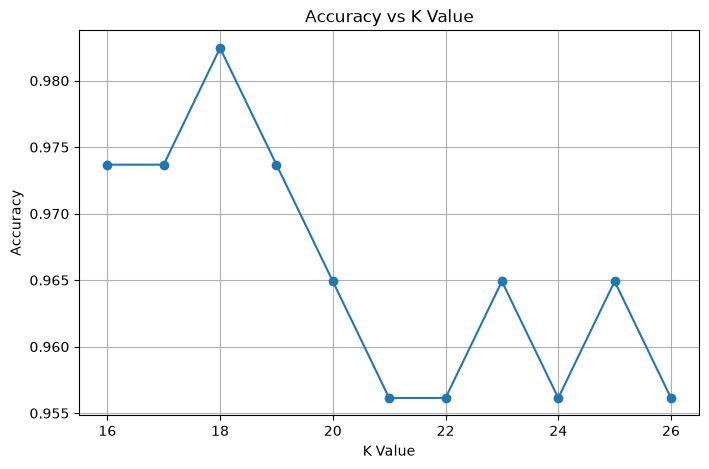

In [18]:
# Plot Accuracy vs K
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.title("Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [19]:
from scipy.spatial.distance import euclidean, cityblock

# Take two samples from the scaled dataset
point1 = X_scaled.iloc[0]
point2 = X_scaled.iloc[1]

# Calculate Euclidean Distance
euclidean_distance = euclidean(point1, point2)

# Calculate Manhattan Distance
manhattan_distance = cityblock(point1, point2)

print("Euclidean Distance:", round(euclidean_distance, 4))
print("Manhattan Distance:", round(manhattan_distance, 4))

Euclidean Distance: 10.3185
Manhattan Distance: 48.3002


In [20]:
from sklearn.decomposition import PCA

# Reduce the dataset to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Display the new shape
print("Original Shape:", X_scaled.shape)
print("Reduced Shape :", X_pca.shape)

Original Shape: (569, 30)
Reduced Shape : (569, 2)


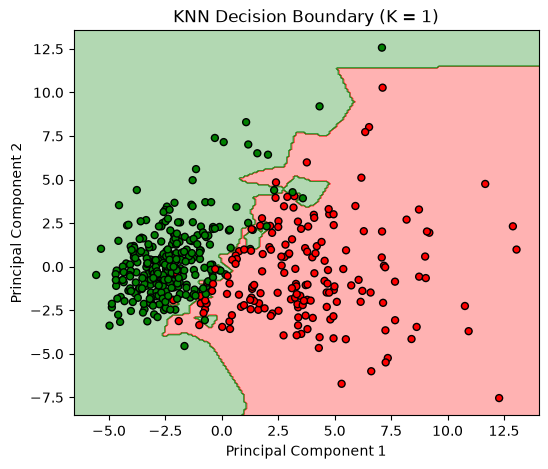

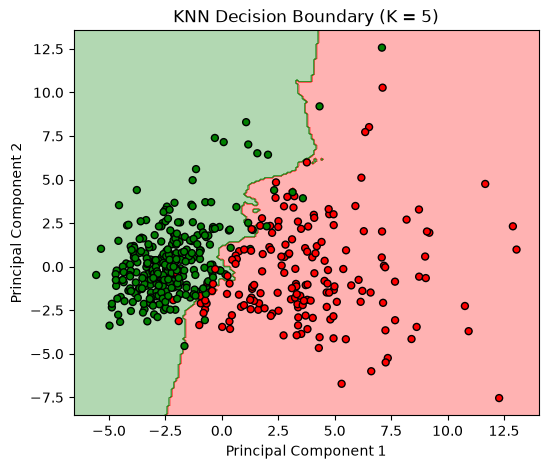

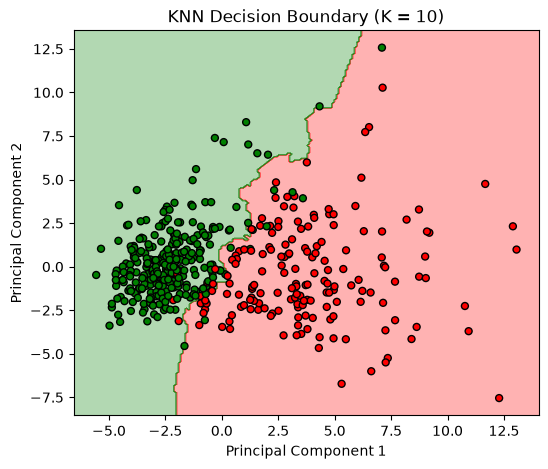

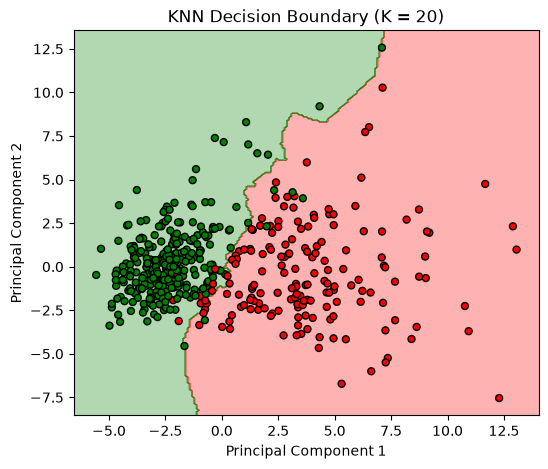

In [21]:
from matplotlib.colors import ListedColormap
import numpy as np

# Split PCA dataset
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Function to plot decision boundary
def plot_decision_boundary(k):

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_pca, y_train_pca)

    x_min, x_max = X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1
    y_min, y_max = X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.1),
        np.arange(y_min, y_max, 0.1)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.3,
                 cmap=ListedColormap(('red', 'green')))

    plt.scatter(
        X_train_pca[:,0],
        X_train_pca[:,1],
        c=y_train_pca,
        cmap=ListedColormap(('red', 'green')),
        edgecolor='k',
        s=25
    )

    plt.title(f"KNN Decision Boundary (K = {k})")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

# Plot for different K values
for k in [1, 5, 10, 20]:
    plot_decision_boundary(k)

In [22]:
from sklearn.model_selection import cross_val_score

# K values to evaluate
k_values = list(range(16, 27))

cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_scaled,
        y,
        cv=5,
        scoring='accuracy'
    )

    cv_scores.append(scores.mean())

# Display mean accuracy for each K
for k, score in zip(k_values, cv_scores):
    print(f"K = {k}, Mean CV Accuracy = {score:.4f}")

K = 16, Mean CV Accuracy = 0.9649
K = 17, Mean CV Accuracy = 0.9578
K = 18, Mean CV Accuracy = 0.9578
K = 19, Mean CV Accuracy = 0.9543
K = 20, Mean CV Accuracy = 0.9526
K = 21, Mean CV Accuracy = 0.9526
K = 22, Mean CV Accuracy = 0.9543
K = 23, Mean CV Accuracy = 0.9543
K = 24, Mean CV Accuracy = 0.9561
K = 25, Mean CV Accuracy = 0.9543
K = 26, Mean CV Accuracy = 0.9526


In [23]:
# Create the final KNN model using the best K value
final_knn = KNeighborsClassifier(n_neighbors=16)

# Train the model
final_knn.fit(X_train_80, y_train_80)

# Predict the test data
y_pred_final = final_knn.predict(X_test_80)

# Predict probabilities for ROC Curve
y_prob = final_knn.predict_proba(X_test_80)[:, 1]

In [24]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test_80, y_pred_final)
precision = precision_score(y_test_80, y_pred_final)
recall = recall_score(y_test_80, y_pred_final)
f1 = f1_score(y_test_80, y_pred_final)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

Accuracy : 0.9737
Precision: 0.9726
Recall   : 0.9861
F1 Score : 0.9793


In [25]:
# Generate confusion matrix
cm = confusion_matrix(y_test_80, y_pred_final)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[40  2]
 [ 1 71]]


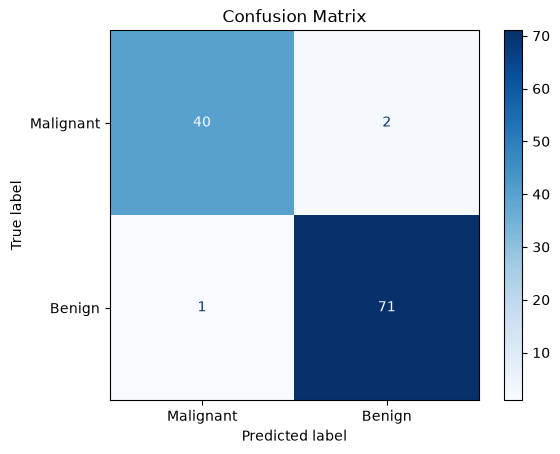

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Malignant", "Benign"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [27]:
# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test_80, y_prob)

# Calculate AUC Score
auc_score = roc_auc_score(y_test_80, y_prob)

print("AUC Score:", round(auc_score,4))

AUC Score: 0.9931


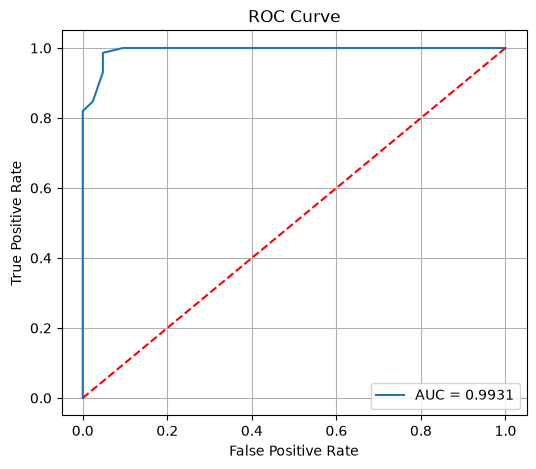

In [28]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(True)

plt.show()